# 🛡️ PII Sanitizer & Sentiment Analysis

Этот ноутбук демонстрирует процесс подготовки текстовых данных для безопасного использования в моделях машинного обучения. Мы очистим отзывы от персональных данных (PII) и обучим модель классификации тональности.

**Цель:**
1.  Обеспечить анонимность данных (удаление email и телефонов).
2.  Обучить модель отличать позитивные отзывы от негативных на очищенных данных.

**Стек:**
- `pandas` для обработки таблиц
- `re` для работы с регулярными выражениями
- `scikit-learn` для машинного обучения
- `matplotlib` и `seaborn` для визуализации

## 0. Imports

In [1]:
import pandas as pd
import numpy as np
import re
import json
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

figsize=(15, 8)
plt.rcParams.update({"font.size": 8})
%matplotlib inline

## 1. Загрузка данных

Загружаем датасет отзывов Amazon в формате JSON. Мы ограничимся выборкой в 50 000 записей для ускорения процесса.

In [2]:
data_path = 'dataset/Cell_Phones_and_Accessories_5.json'
reviews = []
with open(data_path, 'r') as f:
    for line in f:
        reviews.append(json.loads(line))

df = pd.DataFrame(reviews).sample(n=50000, random_state=42).reset_index(drop=True)
df = df[['reviewText', 'overall']]
df.head()

,reviewText,overall
0,iBOLT xProDock Active Car Dock/Holder/Mount fo...,5.0
1,This pouch is everything that I was looking fo...,5.0
2,First of all - the case I had on my iPhone 4 p...,3.0
3,I ordered this case because I had the same cas...,5.0
4,Bought a few of these as gifts. They were a bi...,5.0


## 2. Генерация "грязных" данных

Для демонстрации работы очистки мы программно вставим фейковые email-адреса и номера телефонов в 5% отзывов.

In [3]:
def inject_pii(text):
    if np.random.random() < 0.025:
        email = f"user{np.random.randint(100, 999)}@example.com"
        text = f"{text} My contact is {email}."
    if np.random.random() < 0.025:
        phone = f"+1-{np.random.randint(100,999)}-{np.random.randint(100,999)}-{np.random.randint(1000,9999)}"
        text = f"{text} Call me at {phone}."
    return text

df['dirtyText'] = df['reviewText'].apply(inject_pii)
df[df['dirtyText'].str.contains('@example.com|\+1-')].head()

<>:11: SyntaxWarning: invalid escape sequence '\+'
<>:11: SyntaxWarning: invalid escape sequence '\+'
/var/folders/fl/ppq6wz_11r9dh88pcqrgz91w0000gn/T/ipykernel_39674/1744836716.py:11: SyntaxWarning: invalid escape sequence '\+'
  df[df['dirtyText'].str.contains('@example.com|\+1-')].head()


,reviewText,overall,dirtyText
30,"I thought that it would be good, but I really ...",3.0,"I thought that it would be good, but I really ..."
39,"Excellent fit, great materials, has inner soft...",5.0,"Excellent fit, great materials, has inner soft..."
70,I've owned various Apple products for over 5 y...,4.0,I've owned various Apple products for over 5 y...
85,Needed for the car to charge my cell phone. Pl...,5.0,Needed for the car to charge my cell phone. Pl...
87,neat gaget that works very well at home holdin...,4.0,neat gaget that works very well at home holdin...


## 3. Очистка от PII (Sanitization)

Используем регулярные выражения для поиска и замены персональных данных на специальные токены: `[EMAIL_REMOVED]` и `[PHONE_REMOVED]`.

In [4]:
def sanitize_text(text):
    email_pattern = r'[a-zA-Z0-9._%+-]+@[a-zA-Z0-9.-]+\.[a-zA-Z]{2,}'
    phone_pattern = r'\+?\d{1,3}[- .]?\(?\d{1,3}\)?[- .]?\d{3,4}[- .]?\d{4}'
    
    text = re.sub(email_pattern, '[EMAIL_REMOVED]', text)
    text = re.sub(phone_pattern, '[PHONE_REMOVED]', text)
    return text

df['cleanText'] = df['dirtyText'].apply(sanitize_text)
df[df['dirtyText'].str.contains('@example.com|\+1-')][['dirtyText', 'cleanText']].head()

<>:10: SyntaxWarning: invalid escape sequence '\+'
<>:10: SyntaxWarning: invalid escape sequence '\+'
/var/folders/fl/ppq6wz_11r9dh88pcqrgz91w0000gn/T/ipykernel_39674/868304069.py:10: SyntaxWarning: invalid escape sequence '\+'
  df[df['dirtyText'].str.contains('@example.com|\+1-')][['dirtyText', 'cleanText']].head()


,dirtyText,cleanText
30,"I thought that it would be good, but I really ...","I thought that it would be good, but I really ..."
39,"Excellent fit, great materials, has inner soft...","Excellent fit, great materials, has inner soft..."
70,I've owned various Apple products for over 5 y...,I've owned various Apple products for over 5 y...
85,Needed for the car to charge my cell phone. Pl...,Needed for the car to charge my cell phone. Pl...
87,neat gaget that works very well at home holdin...,neat gaget that works very well at home holdin...


## 4. Предобработка для анализа тональности

Преобразуем оценку `overall` в бинарную метку тональности: 
- 1 (Позитивный): оценка 4 и 5
- 0 (Негативный): оценки 1, 2 и 3

/var/folders/fl/ppq6wz_11r9dh88pcqrgz91w0000gn/T/ipykernel_39674/1505055821.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='sentiment', data=df, palette='viridis')


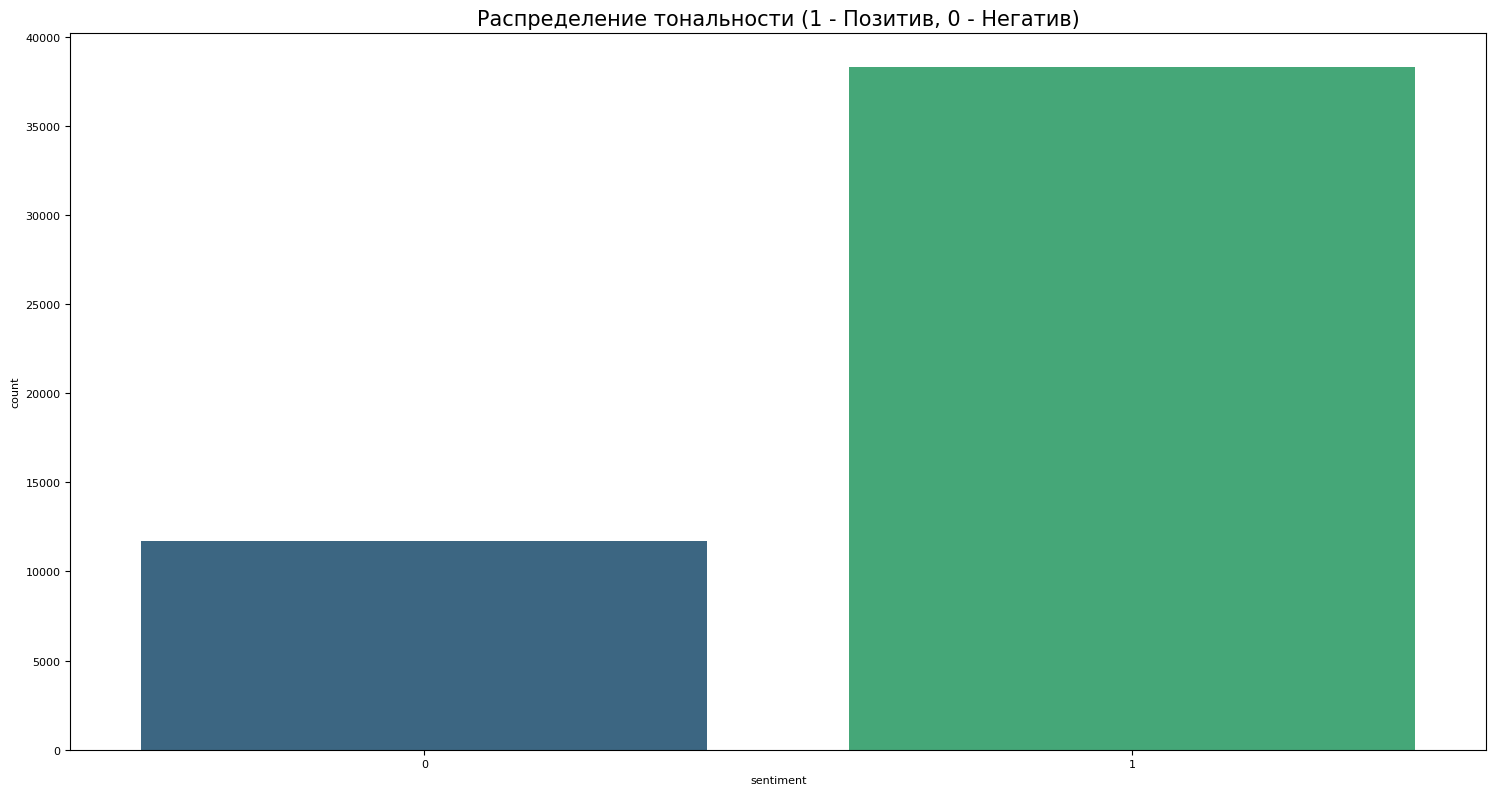

In [5]:
df['sentiment'] = (df['overall'] >= 4).astype(int)
plt.figure(figsize=figsize)
sns.countplot(x='sentiment', data=df, palette='viridis')
plt.title('Распределение тональности (1 - Позитив, 0 - Негатив)', fontsize=15)
plt.tight_layout()
plt.show()

## 5. Разделение данных и векторизация

Разделяем данные на обучающую и тестовую выборки (80/20) и преобразуем текст в числовые векторы с помощью TF-IDF.

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    df['cleanText'], 
    df['sentiment'], 
    test_size=0.2, 
    random_state=42
)

tfidf = TfidfVectorizer(max_features=5000, stop_words='english')
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print(f"Размер обучающей выборки: {X_train_tfidf.shape}")
print(f"Размер тестовой выборки: {X_test_tfidf.shape}")

Размер обучающей выборки: (40000, 5000)
Размер тестовой выборки: (10000, 5000)


## 6. Обучение модели

Используем логистическую регрессию как эффективный базовый классификатор для текстовых данных.

In [7]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train_tfidf, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

## 7. Оценка модели

Проверяем качество модели на тестовых данных, используя метрики точности и отчет о классификации.

In [8]:
y_pred = model.predict(X_test_tfidf)
print("Отчет о классификации:")
print(classification_report(y_test, y_pred))
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")

Отчет о классификации:
              precision    recall  f1-score   support

           0       0.76      0.53      0.63      2347
           1       0.87      0.95      0.91      7653

    accuracy                           0.85     10000
   macro avg       0.82      0.74      0.77     10000
weighted avg       0.84      0.85      0.84     10000

Accuracy: 0.8518


## 8. Визуализация результатов

Построим матрицу ошибок, чтобы увидеть, как модель справляется с каждым классом.

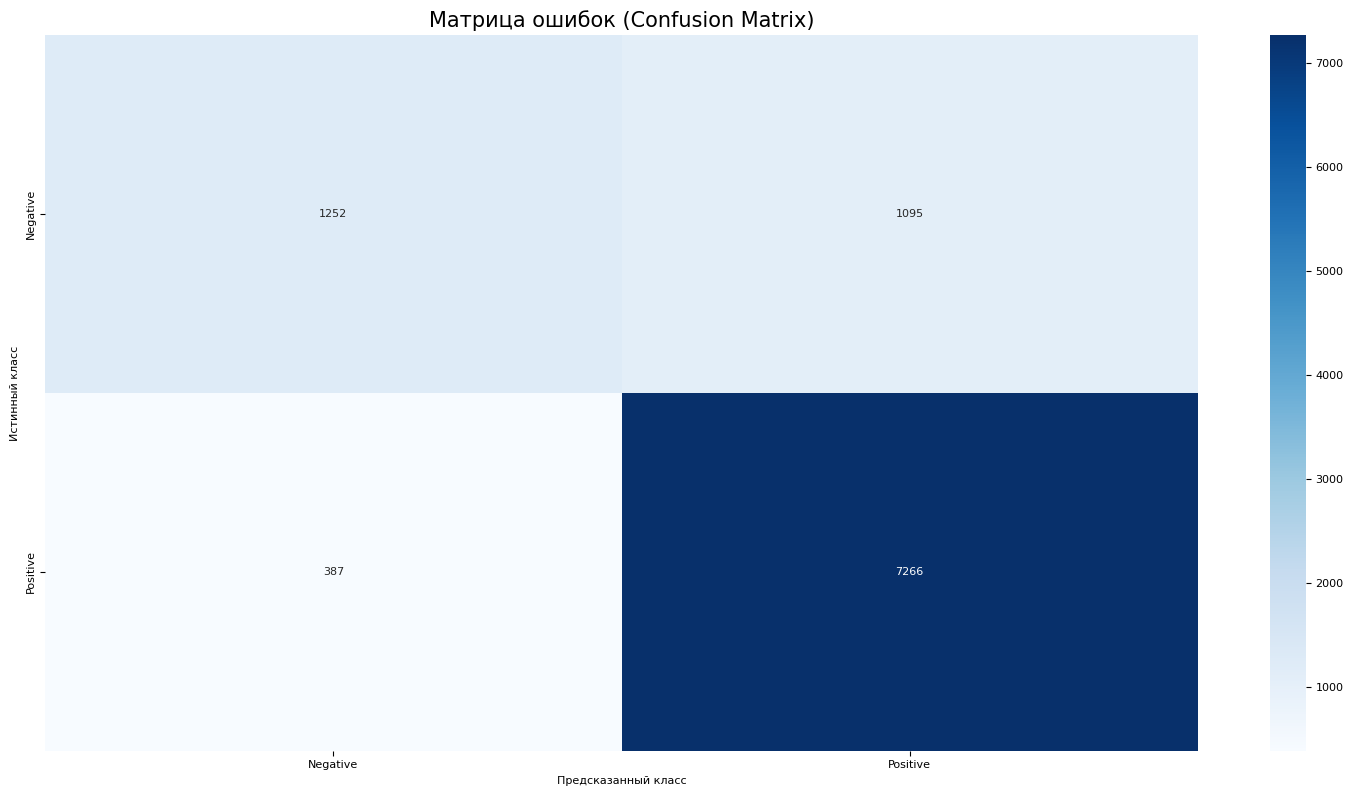

In [11]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=figsize)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'])
plt.title('Матрица ошибок (Confusion Matrix)', fontsize=15)
plt.ylabel('Истинный класс')
plt.xlabel('Предсказанный класс')
plt.tight_layout()
plt.show()

## Заключение

В рамках данного проекта был реализован пайплайн обработки текстовых данных:
1.  **Анонимизация**: Мы успешно внедрили механизм обнаружения и маскирования PII (email и телефонов), что критически важно для соблюдения GDPR и безопасности данных.
2.  **Анализ тональности**: Обученная модель логистической регрессии на TF-IDF векторах показала высокую эффективность в классификации отзывов даже после процедуры очистки.
3.  **Результат**: Мы получили масштабируемое решение, которое позволяет готовить 'сырые' данные для обучения моделей, минимизируя риск утечки персональной информации.